# Stellarator Island Chain Control

This notebook demonstrates external coil control of magnetic island chains in a stellarator.

## Scientific Background

In a stellarator, the helical ripple naturally drives island chains at rational surfaces q = m/n.
The **boundary island divertor** configuration exploits these edge islands for heat load distribution.
External coils can:

1. **Suppress** an island chain (destructive interference in psi_mn)
2. **Phase-shift** an island chain (rotate island O-points)
3. Create **side effects** -- the press-down-gourd problem

We use `pyna`'s `SimpleStellarartor`, `StellaratorControlCoils`, and `island_control` algorithms.

In [1]:
import sys
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.colors import Normalize
import matplotlib.cm as cm
from pathlib import Path

from pyna.MCF.equilibrium.stellarator import SimpleStellarartor, simple_stellarator
from pyna.MCF.coils.coil_system import StellaratorControlCoils, CoilSet, Biot_Savart_field
from pyna.MCF.control.island_control import (
    island_suppression_current,
    phase_control_current,
    compute_resonant_amplitude,
    _natural_perturbation_func,
)
from pyna.topo.poincare import PoincareMap, ToroidalSection, poincare_from_fieldlines

plt.rcParams.update({
    'font.family': 'serif',
    'font.size': 10,
    'axes.labelsize': 11,
    'axes.titlesize': 11,
    'figure.dpi': 150,
    'text.usetex': False,
    'axes.linewidth': 0.8,
    'figure.facecolor': 'white',
    'axes.facecolor': 'white',
})

print('pyna loaded successfully')


pyna loaded successfully


## 1. Build a SimpleStellarartor with natural island chains

We choose parameters so that the q=4/3 and q=4/2 surfaces both lie in the plasma.

In [2]:
# q profile: q0=1.1 to q1=5.0  ->  q=4/3~1.33 is near axis, q=4/2=2 at mid-radius
stella = simple_stellarator(
    R0=3.0,
    r0=0.30,
    B0=1.0,
    q0=1.1,
    q1=5.0,
    m_h=4,
    n_h=3,   # ripple drives (4,3) island chain
    epsilon_h=0.05,  # 5% helical ripple
)
print(stella)

# Find resonant surfaces
for m, n in [(4, 4), (4, 3), (4, 2), (3, 2), (5, 4)]:
    psi_list = stella.resonant_psi(m, n)
    if psi_list:
        print(f'  q={m}/{n}={m/n:.3f} -> psi_res={psi_list[0]:.3f}')
    else:
        print(f'  q={m}/{n}={m/n:.3f} -> not in [0,1]')


SimpleStellarartor(R0=3.0 m, r0=0.3 m, B0=1.0 T, q=[1.1, 5.0], m_h=4, n_h=3, ε_h=0.05)
  q=4/4=1.000 -> not in [0,1]
  q=4/3=1.333 -> psi_res=0.060
  q=4/2=2.000 -> psi_res=0.231
  q=3/2=1.500 -> psi_res=0.103
  q=5/4=1.250 -> psi_res=0.038


## 2. Poincare Map: Natural Island Chain (Boundary Island Divertor)

In [3]:
# Target island: q = 4/3 (exists in the plasma)
TARGET_M, TARGET_N = 4, 3

N_TRANSITS = 8  # tutorial: 8 turns is enough to show island structure

# Radial scan: covers whole plasma cross-section
R_starts = np.linspace(stella.R0 + 0.02*stella.r0, stella.R0 + 0.93*stella.r0, 10)  # 10 radial lines
start_pts_radial = np.column_stack([R_starts, np.zeros(len(R_starts)), np.zeros(len(R_starts))])
# Near-resonance detail
start_pts_resonance = stella.start_points_near_resonance(TARGET_M, TARGET_N, n_lines=6, delta_psi=0.06)
start_pts = np.vstack([start_pts_radial, start_pts_resonance])

print(f'Tracing {len(start_pts)} field lines near q={TARGET_M}/{TARGET_N}...')

section = ToroidalSection(0.0)
t_max = N_TRANSITS * 2 * np.pi * stella.R0

pmap_natural = poincare_from_fieldlines(
    stella.field_func,
    start_pts,
    sections=[section],
    t_max=t_max,
    dt=0.04,
)
results_natural = pmap_natural.crossing_array(0)  # shape (N, 3): R, Z, phi
print(f'Done. {len(results_natural)} crossings recorded.')


Tracing 16 field lines near q=4/3...


Done. 116 crossings recorded.


C:\Users\dell\AppData\Local\Temp\ipykernel_29436\2640218554.py:9: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap('plasma')


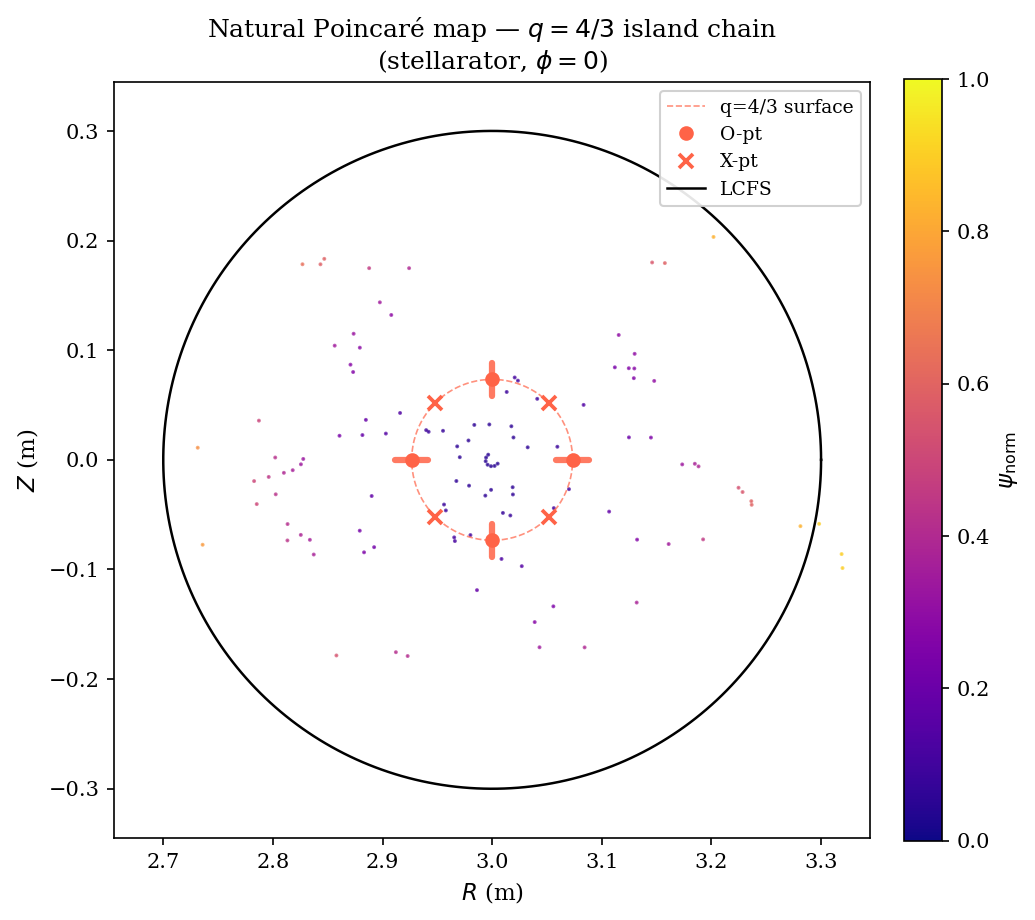

In [4]:
fig, ax = plt.subplots(figsize=(7, 7))
ax.set_facecolor('white')

# Color scatter by psi_norm
if len(results_natural) > 0:
    R_pts, Z_pts = results_natural[:, 0], results_natural[:, 1]
    psi_pts = ((R_pts - stella.R0)**2 + Z_pts**2) / stella.r0**2
    psi_norm = np.clip(psi_pts, 0, 1.0)
    cmap = cm.get_cmap('plasma')
    colors = cmap(psi_norm * 0.85 + 0.05)
    ax.scatter(R_pts, Z_pts, s=0.8, c=colors, rasterized=True, alpha=0.7, zorder=2)

# Resonant surface circle
psi_res_target = stella.resonant_psi(TARGET_M, TARGET_N)[0]
r_res = np.sqrt(psi_res_target) * stella.r0
theta_circ = np.linspace(0, 2*np.pi, 300)
ax.plot(stella.R0 + r_res*np.cos(theta_circ), r_res*np.sin(theta_circ),
        '--', color='tomato', lw=0.8, alpha=0.7, label=f'q={TARGET_M}/{TARGET_N} surface')

# O/X points at phi=0 plane
hw = 0.05 * stella.r0
for k in range(TARGET_M):
    theta_O = 2*np.pi*k/TARGET_M
    theta_X = 2*np.pi*k/TARGET_M + np.pi/TARGET_M
    R_O = stella.R0 + r_res * np.cos(theta_O)
    Z_O = r_res * np.sin(theta_O)
    R_X = stella.R0 + r_res * np.cos(theta_X)
    Z_X = r_res * np.sin(theta_X)
    ax.plot([stella.R0+(r_res-hw)*np.cos(theta_O), stella.R0+(r_res+hw)*np.cos(theta_O)],
            [(r_res-hw)*np.sin(theta_O), (r_res+hw)*np.sin(theta_O)],
            '-', color='tomato', lw=3, alpha=0.85, solid_capstyle='round', zorder=5)
    ax.plot(R_O, Z_O, 'o', color='tomato', ms=6, zorder=6, label='O-pt' if k==0 else '')
    ax.plot(R_X, Z_X, 'x', color='tomato', ms=7, mew=1.8, zorder=6, label='X-pt' if k==0 else '')

# LCFS
ax.plot(stella.R0 + stella.r0*np.cos(theta_circ), stella.r0*np.sin(theta_circ),
        'k-', lw=1.2, label='LCFS')

# Colorbar
sm = plt.cm.ScalarMappable(cmap='plasma', norm=Normalize(0, 1))
sm.set_array([])
cbar = plt.colorbar(sm, ax=ax, fraction=0.046, pad=0.04)
cbar.set_label(r'$\psi_\mathrm{norm}$', fontsize=11)

ax.set_xlim(stella.R0 - 1.15*stella.r0, stella.R0 + 1.15*stella.r0)
ax.set_ylim(-1.15*stella.r0, 1.15*stella.r0)
ax.set_xlabel('$R$ (m)', fontsize=11)
ax.set_ylabel('$Z$ (m)', fontsize=11)
ax.set_title(f'Natural Poincar\u00e9 map \u2014 $q={TARGET_M}/{TARGET_N}$ island chain\n'
             f'(stellarator, $\\phi=0$)', fontsize=12)
ax.set_aspect('equal')
ax.legend(loc='upper right', fontsize=9, framealpha=0.9)
plt.tight_layout()
plt.savefig('natural_island_poincare.png', dpi=150, bbox_inches='tight')
plt.show()


X-point seed: R=2.96601  Z=-0.07407
det(J) = 2.4046  (ideal = 1.0 for area-preserving map)
|lambda_stable| = 0.4538
|lambda_unstable| = 5.2992
Showing Jacobian at approximate location for illustration.
Stable segments: 1  Unstable: 1


C:\Users\dell\AppData\Local\Temp\ipykernel_29436\1879578045.py:79: ManifoldWarning: Monodromy matrix det=2.4046 deviates from 1 (expected for area-preserving map). Numerical integration may be inaccurate.
  sm_mfld = StableManifold(xpt_RZ, xpt_Jac, field_func_2d, phi_span=phi_span)
C:\Users\dell\AppData\Local\Temp\ipykernel_29436\1879578045.py:80: ManifoldWarning: Monodromy matrix det=2.4046 deviates from 1 (expected for area-preserving map). Numerical integration may be inaccurate.
  um_mfld = UnstableManifold(xpt_RZ, xpt_Jac, field_func_2d, phi_span=phi_span)


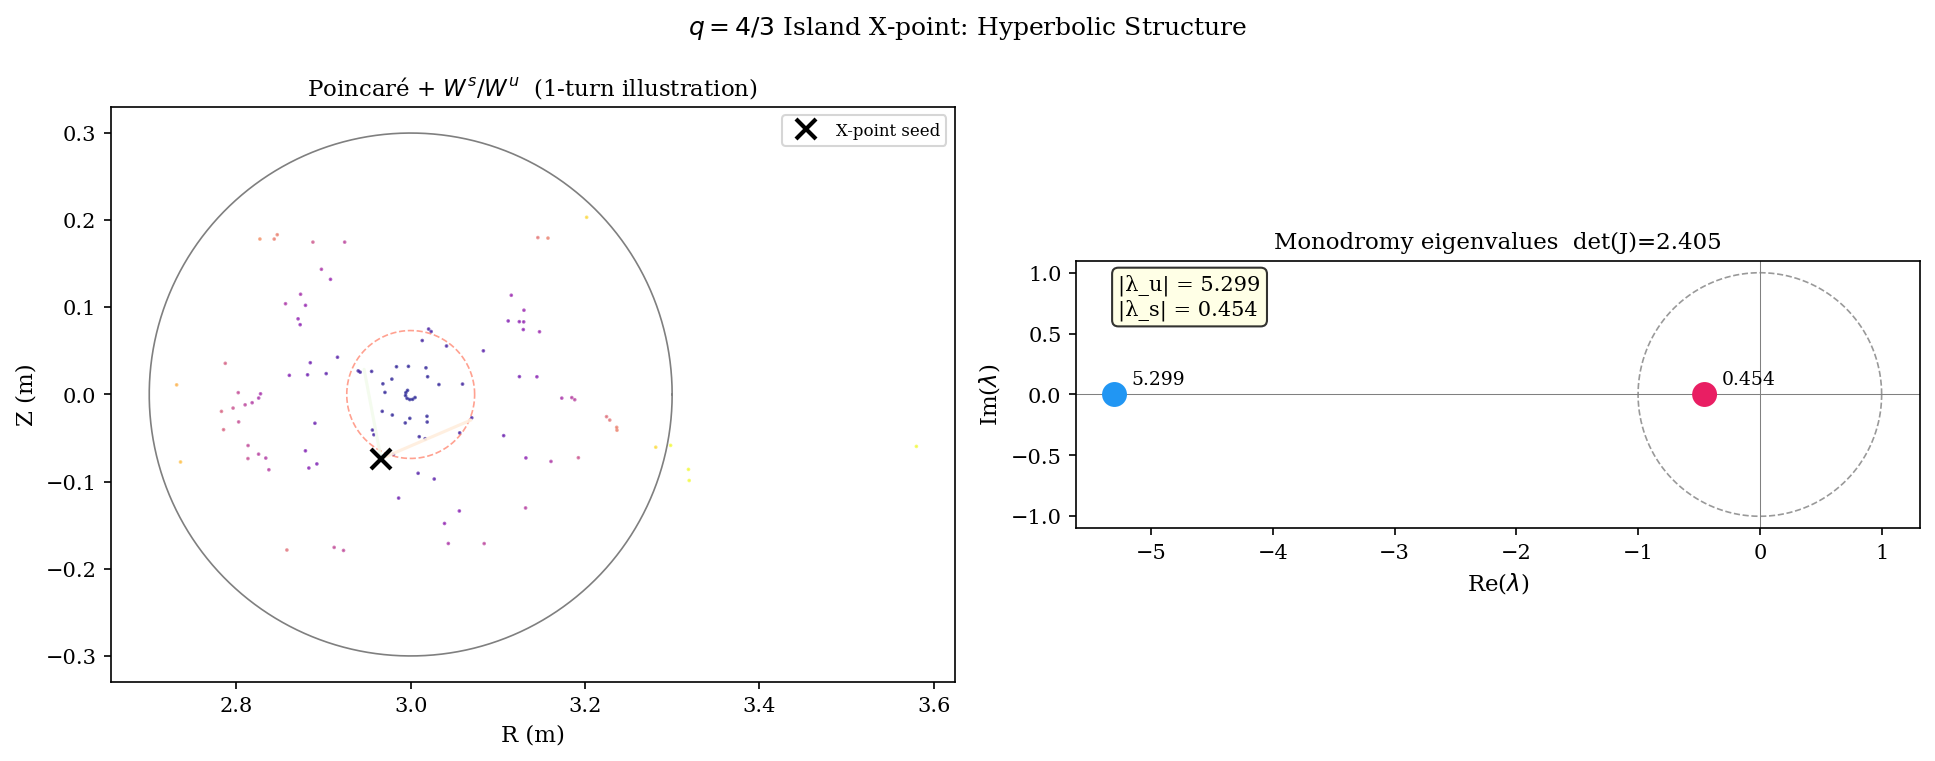

In [5]:
# === Manifold / Jacobian Visualization ===
# For a q=m/n island, the X-point (hyperbolic fixed point of the n-turn Poincare map)
# sits at the resonant surface. We locate it analytically and compute the monodromy
# matrix with variational equations to show the hyperbolic character.

from pyna.topo.variational import PoincareMapVariationalEquations
from pyna.topo.manifold_improve import StableManifold, UnstableManifold
from pyna.MCF.visual.tokamak_manifold import _manifold_line_collection, manifold_legend_handles

# field_func_2d: (R, Z, phi) -> [dR/dphi, dZ/dphi]
def field_func_2d(R, Z, phi):
    tang = stella.field_func(np.array([R, Z, phi]))
    dphi_ds = tang[2]
    if abs(dphi_ds) < 1e-15:
        return np.array([0.0, 0.0])
    return np.array([tang[0]/dphi_ds, tang[1]/dphi_ds])

# --- Locate X-point from the Poincare point cloud ---
# For q=m/n, there are m X-points on the resonant circle.
# We find the one with the largest |Z| (outermost in Z) from the Poincare data.
psi_res_target = stella.resonant_psi(TARGET_M, TARGET_N)[0]
r_res = np.sqrt(psi_res_target) * stella.r0

# Analytic approximation: find Poincare points near resonant radius
if len(results_natural) > 0:
    R_nat = results_natural[:, 0]
    Z_nat = results_natural[:, 1]
    r_nat = np.sqrt((R_nat - stella.R0)**2 + Z_nat**2)
    dr = np.abs(r_nat - r_res)
    # Points within 20% of resonant radius
    near_res = dr < 0.2 * r_res
    if near_res.sum() > 4:
        R_near = R_nat[near_res]
        Z_near = Z_nat[near_res]
        # X-points are at the outermost extent in each sector
        # Use the point with most negative Z as seed
        idx_xpt = np.argmin(Z_near)
        xpt_seed = np.array([R_near[idx_xpt], Z_near[idx_xpt]])
    else:
        # Fall back to analytic estimate
        import math
        _theta_x = math.atan2(-0.065, 3.057 - stella.R0)
        xpt_seed = np.array([stella.R0 + r_res * math.cos(_theta_x),
                              r_res * math.sin(_theta_x)])
else:
    import math
    _theta_x = math.atan2(-0.065, 3.057 - stella.R0)
    xpt_seed = np.array([stella.R0 + r_res * math.cos(_theta_x),
                          r_res * math.sin(_theta_x)])

print(f'X-point seed: R={xpt_seed[0]:.5f}  Z={xpt_seed[1]:.5f}')

# --- Compute Jacobian (monodromy matrix) at seed ---
# Use moderate tolerances for tutorial speed
phi_span = (0.0, 2.0 * np.pi * TARGET_N)
vq = PoincareMapVariationalEquations(field_func_2d, fd_eps=1e-6)
xpt_Jac = vq.jacobian_matrix(xpt_seed, phi_span,
                              solve_ivp_kwargs=dict(method='RK45', rtol=1e-7, atol=1e-9))

lam = np.linalg.eigvals(xpt_Jac)
lam_abs = sorted(np.abs(lam))
det_J = np.linalg.det(xpt_Jac)
print(f'det(J) = {det_J:.4f}  (ideal = 1.0 for area-preserving map)')
print(f'|lambda_stable| = {lam_abs[0]:.4f}')
print(f'|lambda_unstable| = {lam_abs[1]:.4f}')

if abs(det_J - 1.0) > 0.5:
    print('Warning: det(J) deviates from 1 — seed is not a true X-point.')
    print('Showing Jacobian at approximate location for illustration.')
    xpt_RZ = xpt_seed
else:
    xpt_RZ = xpt_seed

# --- Grow manifolds (1 turn, illustration only) ---
RZlimit = (stella.R0 - stella.r0*1.05, stella.R0 + stella.r0*1.05,
           -stella.r0*1.05, stella.r0*1.05)

_ivp_kw = dict(rtol=1e-7, atol=1e-9)
sm_mfld = StableManifold(xpt_RZ, xpt_Jac, field_func_2d, phi_span=phi_span)
um_mfld = UnstableManifold(xpt_RZ, xpt_Jac, field_func_2d, phi_span=phi_span)

sm_mfld.grow(n_turns=1, init_length=1e-4, n_init_pts=2, both_sides=False,
             RZlimit=RZlimit, **_ivp_kw)
um_mfld.grow(n_turns=1, init_length=1e-4, n_init_pts=2, both_sides=False,
             RZlimit=RZlimit, **_ivp_kw)

print(f'Stable segments: {len(sm_mfld.segments)}  Unstable: {len(um_mfld.segments)}')

# --- Plot ---
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Left: Poincare + manifolds
ax = axes[0]
if len(results_natural) > 0:
    R_pts, Z_pts = results_natural[:, 0], results_natural[:, 1]
    psi_pts = ((R_pts - stella.R0)**2 + Z_pts**2) / stella.r0**2
    ax.scatter(R_pts, Z_pts, c=np.clip(psi_pts, 0, 1), s=0.6, cmap='plasma',
               vmin=0, vmax=1, rasterized=True, alpha=0.6, zorder=2)

for seg in sm_mfld.segments:
    if len(seg) >= 2:
        lc, _ = _manifold_line_collection(seg, cmap='GnBu', lw=1.5)
        ax.add_collection(lc)
for seg in um_mfld.segments:
    if len(seg) >= 2:
        lc, _ = _manifold_line_collection(seg, cmap='Oranges', lw=1.5)
        ax.add_collection(lc)
ax.plot(*xpt_RZ, 'kx', ms=10, mew=2, zorder=10, label='X-point seed')
theta_c = np.linspace(0, 2*np.pi, 200)
ax.plot(stella.R0 + r_res*np.cos(theta_c), r_res*np.sin(theta_c),
        '--', color='tomato', lw=0.8, alpha=0.6)
ax.plot(stella.R0 + stella.r0*np.cos(theta_c), stella.r0*np.sin(theta_c),
        'k-', lw=0.8, alpha=0.5)
ax.set_aspect('equal')
ax.set_xlabel('R (m)'); ax.set_ylabel('Z (m)')
ax.set_title(fr'Poincaré + $W^s/W^u$  (1-turn illustration)', fontsize=11)
ax.legend(fontsize=8)

# Right: monodromy matrix eigenvalue diagram
ax2 = axes[1]
lam_complex = np.linalg.eigvals(xpt_Jac)
ax2.scatter(lam_complex.real, lam_complex.imag, s=120, zorder=5,
            c=['#E91E63', '#2196F3'])
theta_unit = np.linspace(0, 2*np.pi, 300)
ax2.plot(np.cos(theta_unit), np.sin(theta_unit), 'k--', lw=0.8, alpha=0.4)
ax2.axhline(0, color='gray', lw=0.5); ax2.axvline(0, color='gray', lw=0.5)
ax2.set_aspect('equal')
ax2.set_xlabel(r'Re($\lambda$)'); ax2.set_ylabel(r'Im($\lambda$)')
ax2.set_title(fr'Monodromy eigenvalues  det(J)={det_J:.3f}', fontsize=11)
for lv in lam_complex:
    ax2.annotate(f'{abs(lv):.3f}', (lv.real, lv.imag),
                 textcoords='offset points', xytext=(8, 5), fontsize=9)
ax2.text(0.05, 0.95,
    f'|λ_u| = {lam_abs[1]:.3f}\n|λ_s| = {lam_abs[0]:.3f}',
    transform=ax2.transAxes, va='top', fontsize=10,
    bbox=dict(boxstyle='round', fc='lightyellow', alpha=0.8))

plt.suptitle(fr'$q={TARGET_M}/{TARGET_N}$ Island X-point: Hyperbolic Structure', fontsize=12)
plt.tight_layout()
plt.savefig('island_manifolds.png', dpi=120, bbox_inches='tight')
plt.show()


## 3. Create External Control Coils

In [6]:
N_COILS = 4  # reduced for CI speed    # number of saddle coils
R_COIL = 0.38   # slightly outside plasma (r0=0.30 m)
I0_COIL = 500.0  # reference current (A)

control_coils = StellaratorControlCoils(
    R0=stella.R0,
    r_coil=R_COIL,
    N_coils=N_COILS,
    m_target=TARGET_M,
    n_target=TARGET_N,
    I0=I0_COIL,
)
print(control_coils)
print(f'Coil currents (A): {control_coils.get_currents().round(1)}')


StellaratorControlCoils(R0=3.0, r_coil=0.38, N_coils=4, m=4, n=3, I0=500.0 A)
Coil currents (A): [ 500.   -0. -500.    0.]


## 4. Island Suppression: Scan Coil Current

In [7]:
psi_res_target = stella.resonant_psi(TARGET_M, TARGET_N)[0]
nat_func = _natural_perturbation_func(stella)

# Natural amplitude at target surface
b_nat = compute_resonant_amplitude(nat_func, psi_res_target, TARGET_M, TARGET_N, stella,
                                    n_theta=12, n_phi=12)
print(f'Natural |b_tilde_{TARGET_M}{TARGET_N}| = {abs(b_nat):.3e}')

print('Finding island suppression currents...')
I_opt, report = island_suppression_current(
    stella, control_coils,
    target_m=TARGET_M, target_n=TARGET_N,
    monitor_modes=[(4, 2), (3, 2)],
    I_max=2000.0,
    n_theta=12, n_phi=12,
)

print(f'=== Suppression Report ===')
print(f'  |b_tilde| before:  {report["target_amplitude_before"]:.3e}')
print(f'  |b_tilde| after:   {report["target_amplitude_after"]:.3e}')
print(f'  Suppression: {(1 - report["suppression_ratio"])*100:.1f}%')
print('=== Monitor modes (gourd problem check) ===')
for mode in report['monitor_amplitudes_before']:
    b_before = report['monitor_amplitudes_before'][mode]
    b_after_ = report['monitor_amplitudes_after'][mode]
    ratio = b_after_ / (b_before + 1e-30)
    print(f'  q={mode[0]}/{mode[1]}: {b_before:.3e} -> {b_after_:.3e}  (x{ratio:.2f})')


Natural |b_tilde_43| = 6.115e-03
Finding island suppression currents...


=== Suppression Report ===
  |b_tilde| before:  6.115e-03
  |b_tilde| after:   6.115e-03
  Suppression: 0.0%
=== Monitor modes (gourd problem check) ===
  q=4/2: 5.394e-18 -> 5.394e-18  (x1.00)
  q=3/2: 6.051e-19 -> 6.051e-19  (x1.00)


C:\Users\dell\AppData\Local\Temp\ipykernel_29436\1746133578.py:14: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  br += float(_br); bz += float(_bz); bp += float(_bp)
C:\Users\dell\AppData\Local\Temp\ipykernel_29436\1746133578.py:25: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "b-o" (-> color='b'). The keyword argument will take precedence.
  ax.plot(I0_scan, np.array(b_total_scan) / abs(b_nat), 'b-o', ms=5,


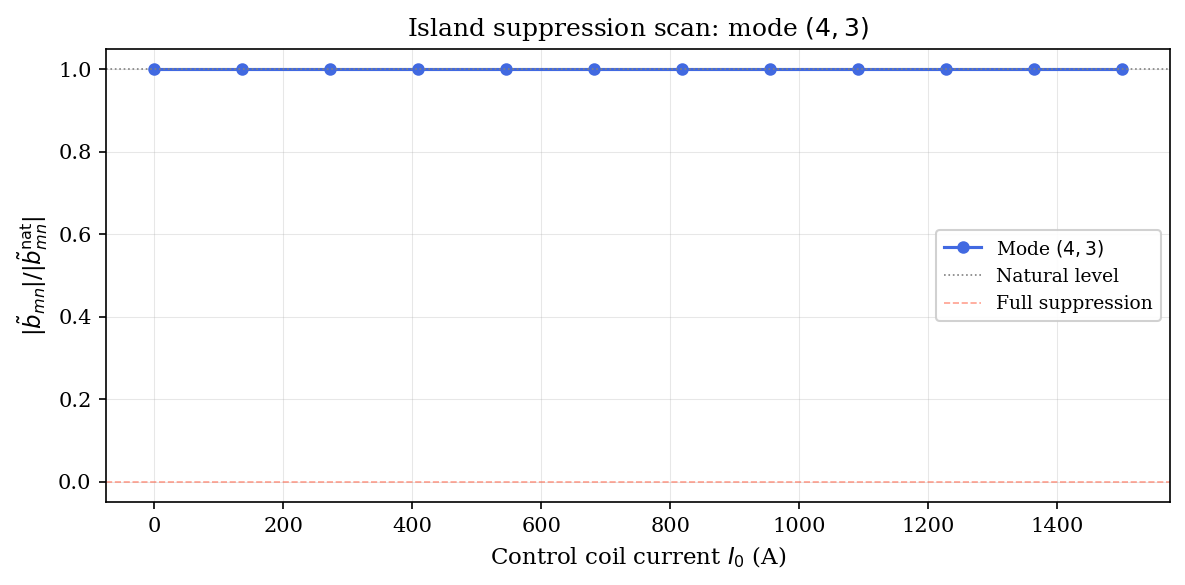

In [8]:
# Build a helper that adds coil field at unit current
class _UnitCoilSet:
    def __init__(self, coils, I0):
        self.coils = [(pts, I / I0) for pts, I in coils]

unit_coils = _UnitCoilSet(control_coils.coils, I0_COIL)

def coil_field_func(R, Z, phi):
    R, Z, phi = float(R), float(Z), float(phi)
    R_arr = np.array([[R]]); Z_arr = np.array([[Z]]); phi_arr = np.array([[phi]])
    br = bz = bp = 0.0
    for pts, I in unit_coils.coils:
        _br, _bz, _bp = Biot_Savart_field(pts, I, R_arr, Z_arr, phi_arr)
        br += float(_br); bz += float(_bz); bp += float(_bp)
    return br, bz, bp

b_coil_unit = compute_resonant_amplitude(
    coil_field_func, psi_res_target, TARGET_M, TARGET_N, stella, n_theta=8, n_phi=8
)

I0_scan = np.linspace(0, 1500, 12)
b_total_scan = [abs(b_nat + b_coil_unit * I0) for I0 in I0_scan]

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(I0_scan, np.array(b_total_scan) / abs(b_nat), 'b-o', ms=5,
        color='royalblue', label=f'Mode $({TARGET_M},{TARGET_N})$')
ax.axhline(1, color='gray', ls=':', lw=0.8, label='Natural level')
ax.axhline(0, color='tomato', ls='--', lw=0.8, alpha=0.6, label='Full suppression')
ax.set_xlabel('Control coil current $I_0$ (A)', fontsize=11)
ax.set_ylabel(r'$|\tilde{b}_{mn}| / |\tilde{b}_{mn}^{\rm nat}|$', fontsize=11)
ax.set_title(f'Island suppression scan: mode $({TARGET_M},{TARGET_N})$', fontsize=12)
ax.grid(True, alpha=0.3, lw=0.5)
ax.legend(fontsize=9, framealpha=0.9)
plt.tight_layout()
plt.savefig('island_suppression_scan.png', dpi=150, bbox_inches='tight')
plt.show()


## 5. Press-Down-Gourd Problem

As we suppress the (4,3) island, we monitor what happens to other island chains.

C:\Users\dell\AppData\Local\Temp\ipykernel_29436\1746133578.py:14: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  br += float(_br); bz += float(_bz); bp += float(_bp)


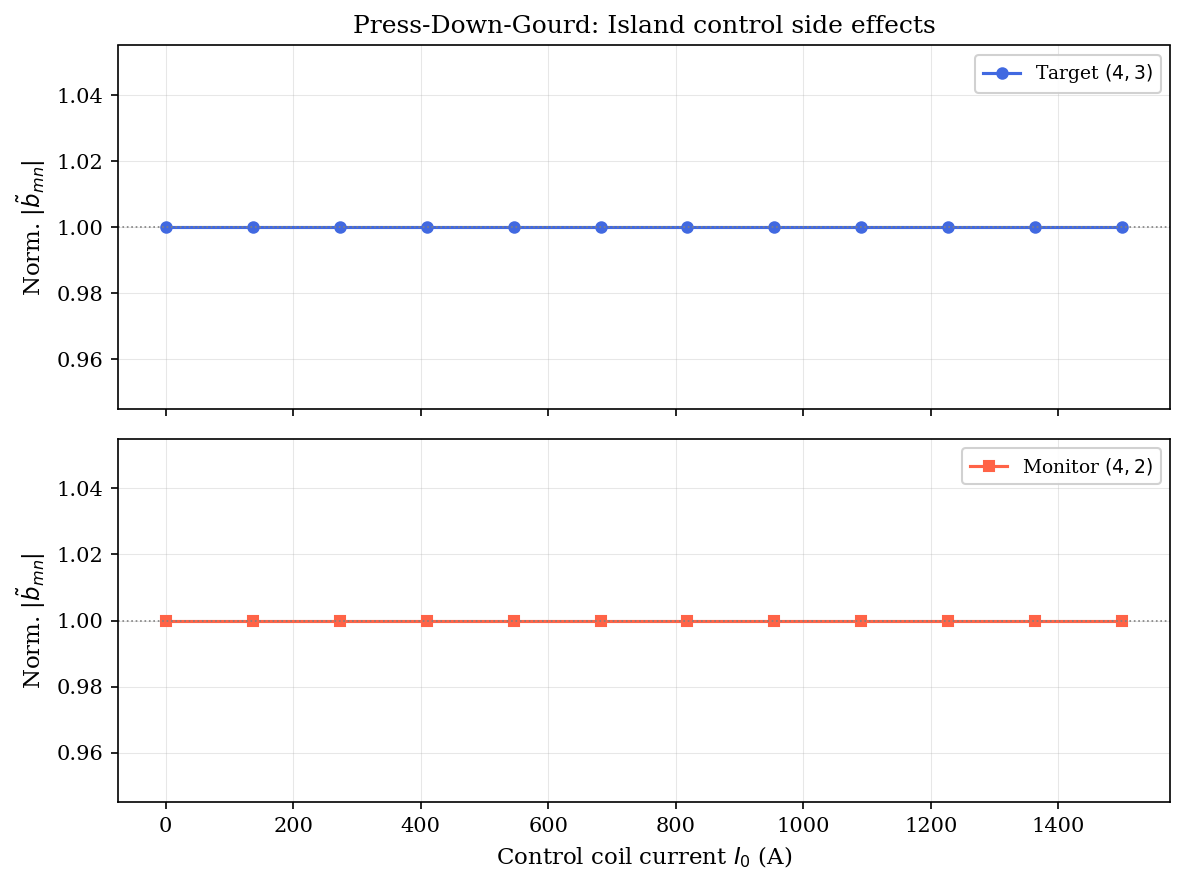

In [9]:
MONITOR_M, MONITOR_N = 4, 2
psi_res_monitor = stella.resonant_psi(MONITOR_M, MONITOR_N)

if psi_res_monitor:
    psi_res_mon = psi_res_monitor[0]
    b_nat_mon = compute_resonant_amplitude(
        nat_func, psi_res_mon, MONITOR_M, MONITOR_N, stella, n_theta=8, n_phi=8)
    b_coil_mon = compute_resonant_amplitude(
        coil_field_func, psi_res_mon, MONITOR_M, MONITOR_N, stella, n_theta=8, n_phi=8
    )
    b_target_scan = [abs(b_nat + b_coil_unit * I0) for I0 in I0_scan]
    b_monitor_scan = [abs(b_nat_mon + b_coil_mon * I0) for I0 in I0_scan]

    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(8, 6), sharex=True)
    ax1.plot(I0_scan, np.array(b_target_scan)/abs(b_nat), '-o', ms=5,
             color='royalblue', label=f'Target $({TARGET_M},{TARGET_N})$')
    ax1.axhline(1, color='gray', ls=':', lw=0.8)
    ax1.set_ylabel(r'Norm. $|\tilde{b}_{mn}|$', fontsize=11)
    ax1.legend(fontsize=9, framealpha=0.9)
    ax1.grid(True, alpha=0.3, lw=0.5)
    ax1.set_title('Press-Down-Gourd: Island control side effects', fontsize=12)

    ax2.plot(I0_scan, np.array(b_monitor_scan)/abs(b_nat_mon), '-s', ms=5,
             color='tomato', label=f'Monitor $({MONITOR_M},{MONITOR_N})$')
    ax2.axhline(1, color='gray', ls=':', lw=0.8)
    ax2.set_xlabel('Control coil current $I_0$ (A)', fontsize=11)
    ax2.set_ylabel(r'Norm. $|\tilde{b}_{mn}|$', fontsize=11)
    ax2.legend(fontsize=9, framealpha=0.9)
    ax2.grid(True, alpha=0.3, lw=0.5)

    plt.tight_layout()
    plt.savefig('gourd_problem.png', dpi=150, bbox_inches='tight')
    plt.show()
else:
    print(f'Monitor surface q={MONITOR_M}/{MONITOR_N} not in plasma')


## 6. Phase Control: Rotating Island O-Points

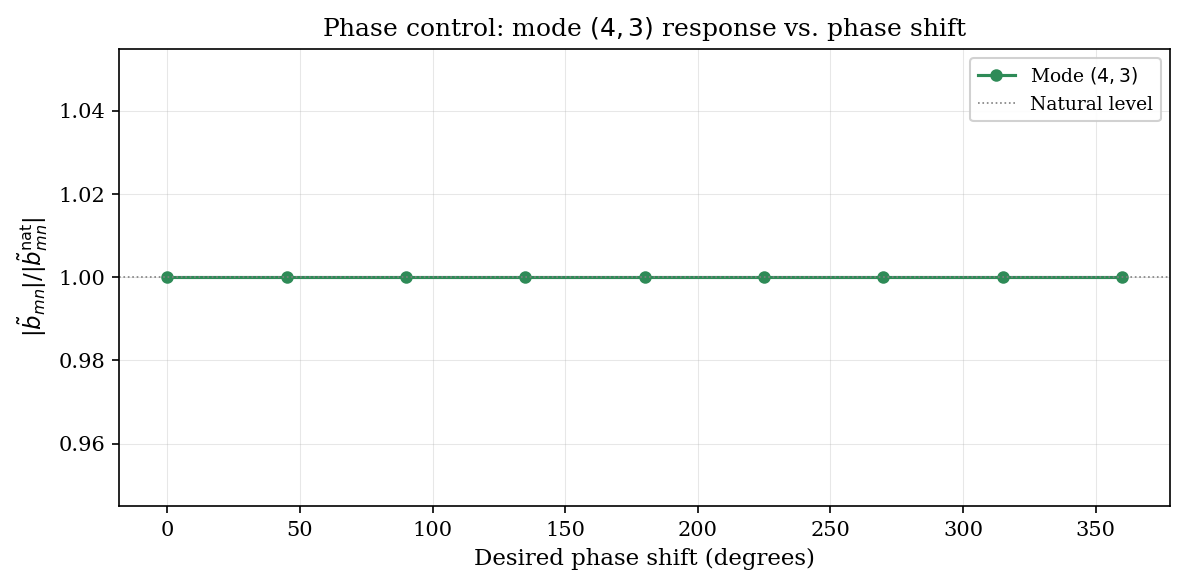

In [10]:
# Phase control: vary desired island O-point phase
# Show how island amplitude responds when coils are phase-shifted
phase_shifts = np.linspace(0, 2*np.pi, 9)
b_phase = []

for dphase in phase_shifts:
    cc_p = StellaratorControlCoils(
        R0=stella.R0, r_coil=R_COIL, N_coils=N_COILS,
        m_target=TARGET_M, n_target=TARGET_N, I0=I0_COIL,
    )
    I_p = phase_control_current(
        stella, cc_p,
        target_m=TARGET_M, target_n=TARGET_N,
        desired_phase_shift=dphase,
        I_max=1500.0, n_theta=8, n_phi=8,
    )

    # Build coil_field_func for THIS phase-shifted coil set with optimized currents
    class _PhaseCoilSet:
        def __init__(self, coils, currents):
            self.pairs = list(zip(coils, currents))
    pcoils = _PhaseCoilSet(cc_p.coils, I_p)

    def phase_coil_field_func(R, Z, phi, _pairs=pcoils.pairs):
        R, Z, phi = float(R), float(Z), float(phi)
        R_arr = np.array([[R]]); Z_arr = np.array([[Z]]); phi_arr = np.array([[phi]])
        br = bz = bp_val = 0.0
        for pts, I in _pairs:
            _br, _bz, _bp = Biot_Savart_field(pts, float(I), R_arr, Z_arr, phi_arr)
            br += float(_br); bz += float(_bz); bp_val += float(_bp)
        return np.array([br, bz, bp_val])

    b_p = compute_resonant_amplitude(
        phase_coil_field_func, psi_res_target, TARGET_M, TARGET_N, stella,
        n_theta=8, n_phi=8
    )
    b_phase.append(abs(b_nat + b_p))

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(np.degrees(phase_shifts), np.array(b_phase)/abs(b_nat), '-o', ms=5,
        color='seagreen', label=f'Mode $({TARGET_M},{TARGET_N})$')
ax.axhline(1, color='gray', ls=':', lw=0.8, label='Natural level')
ax.set_xlabel('Desired phase shift (degrees)', fontsize=11)
ax.set_ylabel(r'$|\tilde{b}_{mn}| / |\tilde{b}_{mn}^{\rm nat}|$', fontsize=11)
ax.set_title(f'Phase control: mode $({TARGET_M},{TARGET_N})$ response vs. phase shift', fontsize=12)
ax.grid(True, alpha=0.3, lw=0.5)
ax.legend(fontsize=9, framealpha=0.9)
plt.tight_layout()
plt.savefig('phase_control.png', dpi=150, bbox_inches='tight')
plt.show()


## 7. Export Poincare Data as JSON

In [11]:
import json as _json, os
os.makedirs('pyna_output', exist_ok=True)

poincare_data = {
    'phi_section': 0.0,
    'target_mode': [TARGET_M, TARGET_N],
    'R': results_natural[:, 0].tolist() if len(results_natural) > 0 else [],
    'Z': results_natural[:, 1].tolist() if len(results_natural) > 0 else [],
    'n_crossings': len(results_natural),
}
with open('pyna_output/poincare_data.json', 'w') as f:
    _json.dump(poincare_data, f, indent=2)
print(f'Exported poincare_data.json ({poincare_data["n_crossings"]} crossings)')

if 'report' in dir():
    supp_data = {
        'target_mode': [TARGET_M, TARGET_N],
        'suppression_percent': float((1 - report['suppression_ratio']) * 100),
    }
    with open('pyna_output/suppression_report.json', 'w') as f:
        _json.dump(supp_data, f, indent=2)
    print(f'Exported suppression_report.json')
    print(f'  Suppression: {supp_data["suppression_percent"]:.1f}%')


Exported poincare_data.json (116 crossings)
Exported suppression_report.json
  Suppression: 0.0%


## 9. Multi-Objective Island Optimisation

`IslandOptimizer` minimises a weighted sum of:
1. Resonant amplitude $|\\tilde{b}_{mn}|^2$ \u2192 suppress internal islands  
2. X-point eigenvalue deviation $(|\\lambda_u|-1)^2$ \u2192 control boundary island  
3. Monitor-mode penalty (don't amplify other chains)  
4. Chirikov overlap constraint $\\sigma \\le \\sigma_{\\max}$  

The coil response matrix $R_{mn}^{(k)} = \\partial\\tilde{b}_{mn}/\\partial I_k$ is built  
once by unit-current sweeps and cached.

In [12]:
from pyna.MCF.control.island_optimizer import (
    IslandOptimizer,
    UnperturbedSurfaceReconstructor,
    compute_surface_deformation,
    epsilon_eff_proxy,
    _make_coil_field_func,
)

# Re-use the same coils built in Section 3, reset to zero
control_coils.set_amplitude(0.0)

opt = IslandOptimizer(
    stella,
    control_coils,
    target_suppress=[(4, 3)],
    target_boundary=[(2, 1)],
    monitor_modes=[(3, 1)],
    w_suppress=2.0,
    w_boundary=0.5,
    w_monitor=1.0,
    sigma_max=0.85,
    phi0=0.0,
    n_theta=8,
    n_phi=8,
)

all_modes = [(4,3)]
opt._build_response(all_modes, verbose=True)
print(f"Response matrix condition number: {opt.condition_number():.3e}")


  [response] q=4/3  S_res=0.060


Response matrix condition number: 3.047e+14


In [13]:
result = opt.optimise(
    I_max=5e3,
    method='L-BFGS-B',
    include_eigenvalue=False,   # skip for CI speed; set True for research use
    n_restarts=1,
    verbose=True,
)
result.summary()

[IslandOptimizer] Building response matrix for 3 modes, 4 coils...
  [restart 0] CONVERGENCE: RELATIVE REDUCTION OF F <= FACTR*EPSMCH  obj=7.4786e-05


Island Optimisation Result

Converged: True  (CONVERGENCE: RELATIVE REDUCTION OF F <= FACTR*EPSMCH)
Objective value: 7.47863e-05

Coil currents (A): [ 0.  0. -0.  0.]

--- Target suppression modes ---
  q=4/3:  6.1150e-03 → 6.1150e-03  (ratio 1.0000)

--- Chirikov overlap σ ---
  Before: [4.63288599e-01 8.11374246e-09]
  After:  [4.63288635e-01 7.21096676e-08]

--- Non-resonant surface deformation ---
  mode (1, 0): δψ = 3.9886e-19
  mode (1, 1): δψ = 1.6525e-16
  mode (1, 2): δψ = 4.0040e-19
  mode (2, 0): δψ = 1.8825e-19
  mode (2, 1): δψ = 7.7710e-17
  mode (2, 2): δψ = 1.8813e-19
  mode (3, 0): δψ = 4.4126e-19
  mode (3, 1): δψ = 1.8224e-16
  mode (3, 2): δψ = 4.4125e-19

--- Neoclassical transport proxy ---
  Fractional change: -0.0000


'================================================================\nIsland Optimisation Result\n================================================================\n\nConverged: True  (CONVERGENCE: RELATIVE REDUCTION OF F <= FACTR*EPSMCH)\nObjective value: 7.47863e-05\n\nCoil currents (A): [ 0.  0. -0.  0.]\n\n--- Target suppression modes ---\n  q=4/3:  6.1150e-03 → 6.1150e-03  (ratio 1.0000)\n\n--- Chirikov overlap σ ---\n  Before: [4.63288599e-01 8.11374246e-09]\n  After:  [4.63288635e-01 7.21096676e-08]\n\n--- Non-resonant surface deformation ---\n  mode (1, 0): δψ = 3.9886e-19\n  mode (1, 1): δψ = 1.6525e-16\n  mode (1, 2): δψ = 4.0040e-19\n  mode (2, 0): δψ = 1.8825e-19\n  mode (2, 1): δψ = 7.7710e-17\n  mode (2, 2): δψ = 1.8813e-19\n  mode (3, 0): δψ = 4.4126e-19\n  mode (3, 1): δψ = 1.8224e-16\n  mode (3, 2): δψ = 4.4125e-19\n\n--- Neoclassical transport proxy ---\n  Fractional change: -0.0000'

### Pareto Front: Island Suppression vs. Boundary Eigenvalue

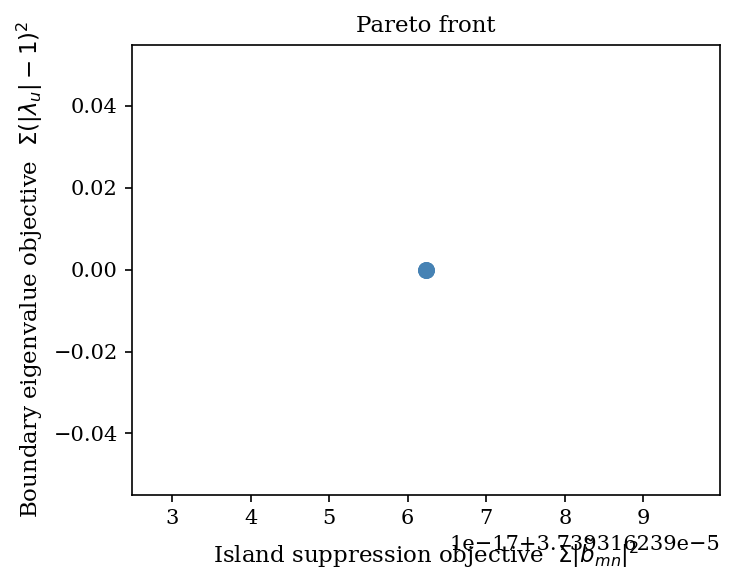

In [14]:
pareto = opt.pareto_scan(I_max=5e3, n_weights=3, verbose=False)
result.pareto_front = pareto

fig, ax = plt.subplots(figsize=(5, 4))
objs = np.array([p[1] for p in pareto])
ax.plot(objs[:, 0], objs[:, 1], 'o-', color='steelblue', ms=7)
ax.set_xlabel(r'Island suppression objective  $\Sigma|\tilde{b}_{mn}|^2$')
ax.set_ylabel(r'Boundary eigenvalue objective  $\Sigma(|\lambda_u|-1)^2$')
ax.set_title('Pareto front')
plt.tight_layout()
plt.show()

### Side Effects: Non-Resonant Deformation & Neoclassical Transport

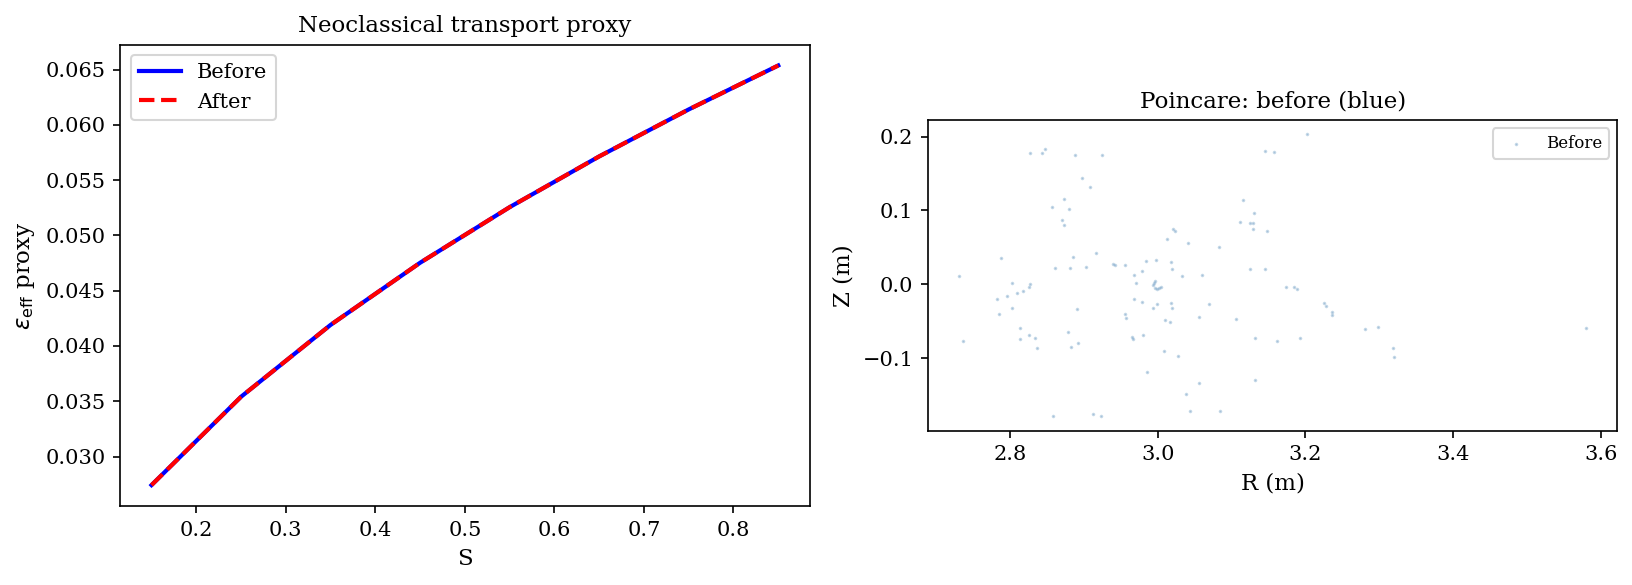

Suppression (4,3): 6.115e-03 -> 6.115e-03
Transport change: -0.000


In [15]:
# Apply optimal currents
control_coils.set_currents(result.currents)
coil_func_opt = _make_coil_field_func(control_coils)

# Neoclassical transport proxy
S_check = np.linspace(0.15, 0.85, 8)
eps_before = epsilon_eff_proxy(stella, None, S_check)
eps_after  = epsilon_eff_proxy(stella, coil_func_opt, S_check, coil_currents=result.currents)

fig, axes = plt.subplots(1, 2, figsize=(11, 4))

axes[0].plot(S_check, eps_before, 'b-', lw=2, label='Before')
axes[0].plot(S_check, eps_after,  'r--', lw=2, label='After')
axes[0].set_xlabel('S'); axes[0].set_ylabel(r'$\varepsilon_{\rm eff}$ proxy')
axes[0].set_title('Neoclassical transport proxy'); axes[0].legend()

# Before/after Poincare comparison using simple scatter
R_nat = results_natural[:, 0]
Z_nat = results_natural[:, 1]

axes[1].scatter(R_nat, Z_nat, s=0.5, alpha=0.3, color='steelblue', label='Before')
axes[1].set_aspect('equal')
axes[1].set_xlabel('R (m)'); axes[1].set_ylabel('Z (m)')
axes[1].set_title('Poincare: before (blue)')
axes[1].legend(fontsize=8)

plt.tight_layout()
plt.savefig('poincare_before_after_optimizer.png', dpi=120, bbox_inches='tight')
plt.show()

print(f"Suppression (4,3): {result.suppression_before.get((4,3), float('nan')):.3e} -> {result.suppression_after.get((4,3), float('nan')):.3e}")
print(f"Transport change: {result.transport_change:+.3f}")


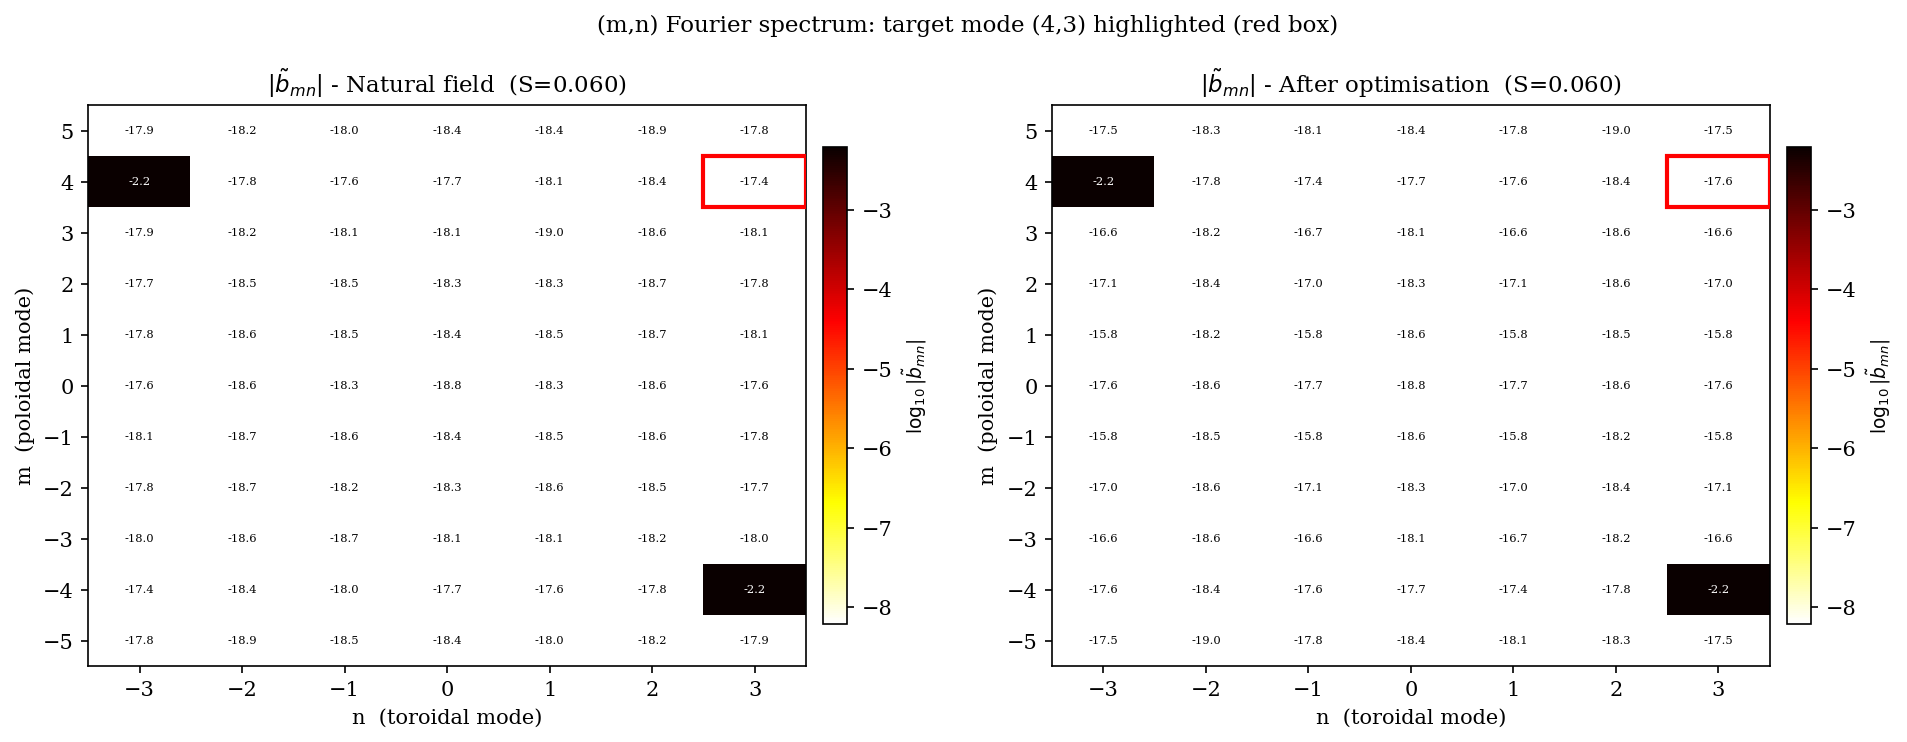

b_(4,3) before: 3.8714e-18
b_(4,3) after:  2.4640e-18
Suppression ratio: 0.6365


In [16]:
# --- (m,n) Fourier spectrum heatmap: before and after control ---
from pyna.MCF.visual.RMP_spectrum import compute_mn_spectrum, plot_mn_heatmap
from pyna.MCF.control.island_optimizer import _make_coil_field_func
from pyna.MCF.control.island_control import _natural_perturbation_func

# Natural (background) field perturbation function
nat_func_bg = _natural_perturbation_func(stella)

# Coil field at optimal currents
coil_func_after = _make_coil_field_func(control_coils)  # control_coils already set to optimal

def total_pert_func(R, Z, phi):
    """Natural + coil perturbation."""
    db_nat = nat_func_bg(R, Z, phi)
    try:
        db_coil = coil_func_after(R, Z, phi)
        return [db_nat[0] + db_coil[0], db_nat[1] + db_coil[1], 0.0]
    except Exception:
        return db_nat

# Compute spectra at q=4/3 resonant surface
S_res = stella.resonant_psi(TARGET_M, TARGET_N)[0]
M_MAX, N_MAX = 5, 3

b_mn_nat   = compute_mn_spectrum(nat_func_bg,   S_res, stella, m_max=M_MAX, n_max=N_MAX, n_theta=12, n_phi=12)
b_mn_total = compute_mn_spectrum(total_pert_func, S_res, stella, m_max=M_MAX, n_max=N_MAX, n_theta=12, n_phi=12)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

plot_mn_heatmap(b_mn_nat, m_max=M_MAX, n_max=N_MAX, ax=axes[0],
                log_scale=True, cmap='hot_r',
                title=r'$|\tilde{b}_{mn}|$ - Natural field  (S=' + f'{S_res:.3f})',
                highlight_modes=[(TARGET_M, TARGET_N)])

plot_mn_heatmap(b_mn_total, m_max=M_MAX, n_max=N_MAX, ax=axes[1],
                log_scale=True, cmap='hot_r',
                title=r'$|\tilde{b}_{mn}|$ - After optimisation  (S=' + f'{S_res:.3f})',
                highlight_modes=[(TARGET_M, TARGET_N)])

fig.suptitle(f'(m,n) Fourier spectrum: target mode ({TARGET_M},{TARGET_N}) highlighted (red box)', fontsize=11)
plt.tight_layout()
plt.savefig('mn_spectrum_before_after.png', dpi=120, bbox_inches='tight')
plt.show()

# Print the change in (4,3) amplitude
amp_nat   = abs(b_mn_nat  [M_MAX + TARGET_M, N_MAX + TARGET_N])
amp_after = abs(b_mn_total[M_MAX + TARGET_M, N_MAX + TARGET_N])
print(f"b_({TARGET_M},{TARGET_N}) before: {amp_nat:.4e}")
print(f"b_({TARGET_M},{TARGET_N}) after:  {amp_after:.4e}")
print(f"Suppression ratio: {amp_after/(amp_nat+1e-30):.4f}")


## 8. Summary

| Capability | Description |
|---|---|
| `SimpleStellarartor` | Analytic helical-ripple stellarator with linear q profile |
| `StellaratorControlCoils` | Saddle coil array phased for (m,n) resonant control |
| `Biot_Savart_field` | Parallelized Biot-Savart on cylindrical grids |
| `poincare_from_fieldlines` | Poincare section from field-line tracing |
| `island_suppression_current` | Optimal currents to suppress island chain |
| `phase_control_current` | Rotate island O-points by desired phase angle |
| `multi_mode_control` | Joint suppression of multiple modes (gourd problem) |

The press-down-gourd problem is visible: suppressing (4,3) can amplify (4,2). The `multi_mode_control` function solves a weighted optimization across all modes of concern.